In [3]:
import pandas as pd
import numpy as np 

import scipy.stats as stats

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

In [4]:
df = pd.read_csv("train (1).csv" , usecols=['Age' , 'Fare' , 'Survived'])

In [6]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [8]:
df['Age'].fillna(df['Age'].mean() , inplace=True)

/tmp/ipykernel_3218/3516665944.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean() , inplace=True)


In [9]:
df.isnull().sum()

Survived    0
Age         0
Fare        0
dtype: int64

In [19]:
X = df.iloc[:,1:3]
y = df.iloc[:,0]

In [20]:
X_train,X_test,Y_train,Y_test = train_test_split(X,y,test_size=0.2 , random_state=42)

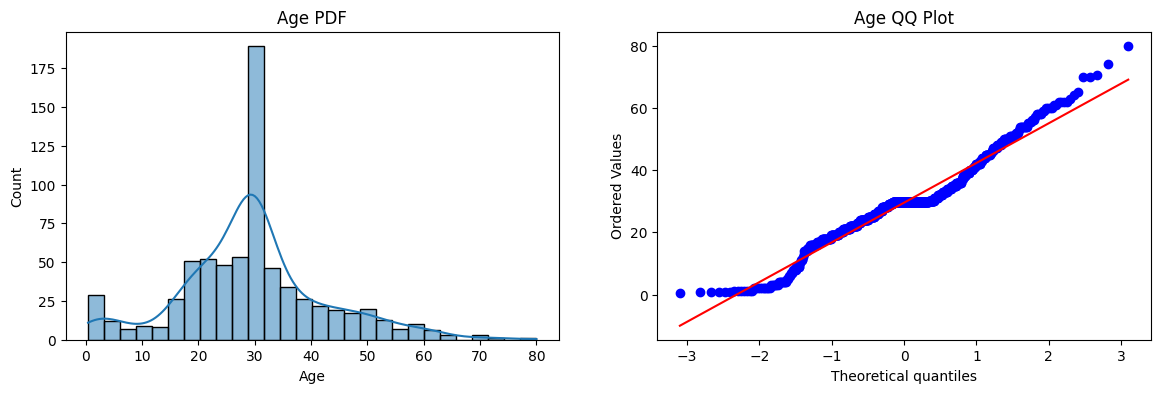

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.figure(figsize=(14,4))

plt.subplot(121)
sns.histplot(X_train['Age'], kde=True)
plt.title('Age PDF')

plt.subplot(122)
stats.probplot(X_train['Age'], dist='norm', plot=plt)
plt.title('Age QQ Plot')

plt.show()

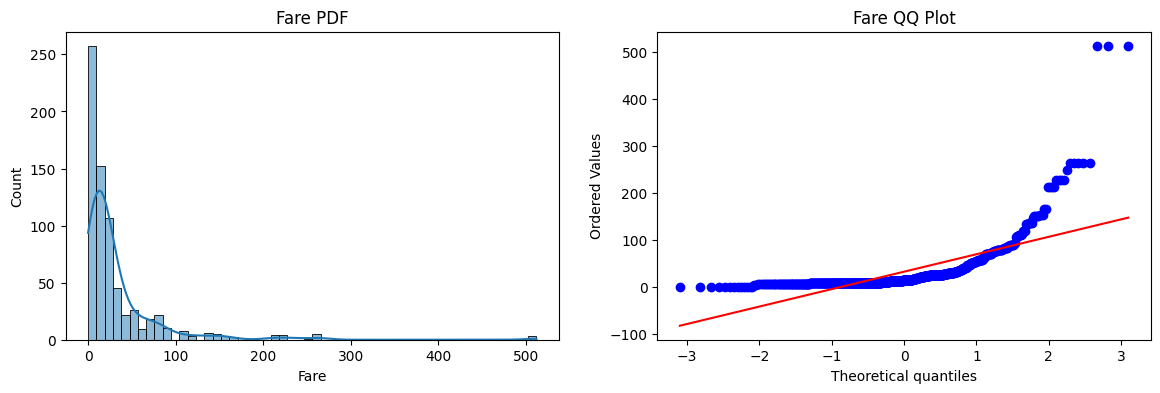

In [24]:
plt.figure(figsize=(14,4))

plt.subplot(121)
sns.histplot(X_train['Fare'], kde=True)
plt.title('Fare PDF')

plt.subplot(122)
stats.probplot(X_train['Fare'], dist='norm', plot=plt)
plt.title('Fare QQ Plot')

plt.show()

In [25]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

In [28]:
clf.fit(X_train,Y_train)
clf2.fit(X_train,Y_train)

y_pred = clf.predict(X_test)
y_pred1 = clf.predict(X_test)

print("Accuracy LR : ", accuracy_score(Y_test , y_pred))
print("Accuracy DT : ", accuracy_score(Y_test,y_pred1))

Accuracy LR :  0.6480446927374302
Accuracy DT :  0.6480446927374302


In [29]:
trf = FunctionTransformer(func=np.log1p)



In [30]:
X_train_transformed = trf.fit_transform(X_train)
X_test_transformed = trf.transform(X_test)

In [34]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf.fit(X_train_transformed,Y_train)
clf2.fit(X_train_transformed, Y_train)

y_pred = clf.predict(X_test)
y_pred1 = clf2.predict(X_test)

print("Accuracy LR : ", accuracy_score(Y_test , y_pred))
print("Accuracy DT : ", accuracy_score(Y_test,y_pred1))

Accuracy LR :  0.7374301675977654
Accuracy DT :  0.5921787709497207


In [35]:
X_transformed = trf.fit_transform(X)

clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

print("Accuracy LR : ", np.mean(cross_val_score(clf,X_transformed,y,scoring='accuracy' , cv=10)))
print("Accuracy DT : ", np.mean(cross_val_score(clf2,X_transformed,y,scoring='accuracy' , cv=10)))

Accuracy LR :  0.678027465667915
Accuracy DT :  0.6666916354556804


Text(0.5, 1.0, 'Fare After Log')

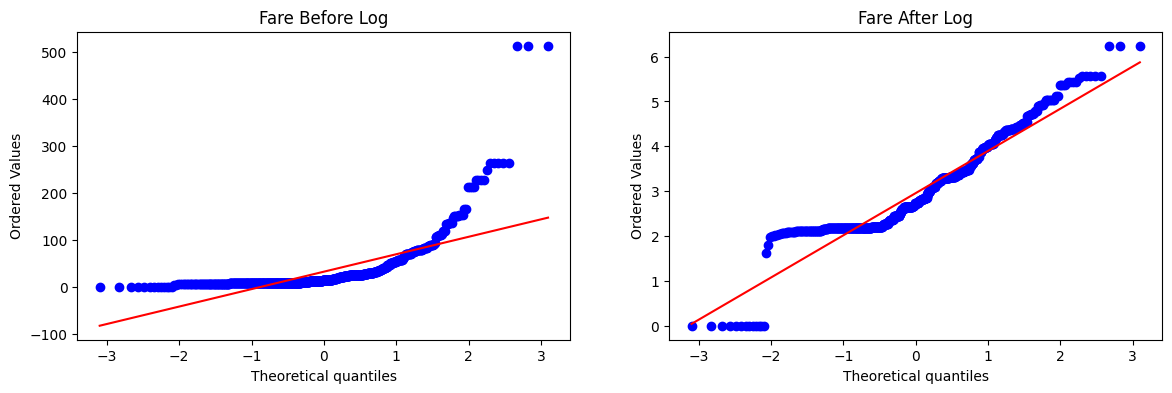

In [37]:
plt.figure(figsize=(14,4))

plt.subplot(121)
stats.probplot(X_train['Fare'] , dist='norm' , plot=plt)
plt.title("Fare Before Log")

plt.subplot(122)
stats.probplot(X_train_transformed['Fare'] , dist='norm' , plot=plt)
plt.title("Fare After Log")

Text(0.5, 1.0, 'Age After Log')

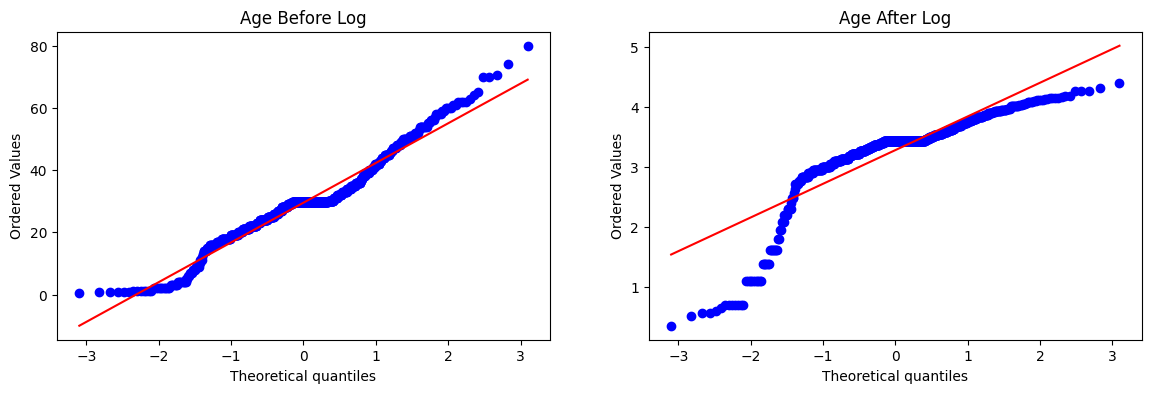

In [38]:
plt.figure(figsize=(14,4))

plt.subplot(121)
stats.probplot(X_train['Age'] , dist='norm' , plot=plt)
plt.title("Age Before Log")

plt.subplot(122)
stats.probplot(X_train_transformed['Age'] , dist='norm' , plot=plt)
plt.title("Age After Log")

In [39]:
trf2 = ColumnTransformer([('log' , FunctionTransformer(np.log1p),['Fare'])],remainder='passthrough')

X_train_transformed2 = trf2.fit_transform(X_train)
X_test_transformed2 = trf2.transform(X_test)

In [40]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf.fit(X_train_transformed2,Y_train)
clf2.fit(X_train_transformed2,Y_train)

y_pred = clf.predict(X_test_transformed2)
y_pred2 = clf2.predict(X_test_transformed2)

print("Accuracy LR : ", accuracy_score(Y_test , y_pred))
print("Accuracy DT : ", accuracy_score(Y_test,y_pred2))

Accuracy LR :  0.6703910614525139
Accuracy DT :  0.6871508379888268


In [41]:
X_transformed2 = trf2.fit_transform(X)

clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

print("Accuracy LR : ", np.mean(cross_val_score(clf,X_transformed2,y,scoring='accuracy' , cv=10)))
print("Accuracy DT : ", np.mean(cross_val_score(clf2,X_transformed2,y,scoring='accuracy' , cv=10)))

Accuracy LR :  0.6712609238451936
Accuracy DT :  0.6565917602996254


In [54]:
def apply_transform(transform):
    X = df.iloc[:,1:3]
    Y = df.iloc[:,0]

    trf = ColumnTransformer([('log' , FunctionTransformer(transform) , ['Fare'])] , remainder='passthrough')

    X_trans = trf.fit_transform(X)
    clf = LogisticRegression()

    print("Accuracy : " , np.mean(cross_val_score(clf,X_trans , Y ,scoring='accuracy' , cv=10)))

    plt.figure(figsize=(14,4))

    plt.subplot(121)
    stats.probplot(X['Fare'] , dist='norm' , plot=plt)
    plt.title('Fare Before Transform')

    plt.subplot(122)
    stats.probplot(X_trans[:,0] , dist='norm' , plot=plt)
    plt.title("Fare After Transform")

    plt.show()

Accuracy :  0.6611485642946316


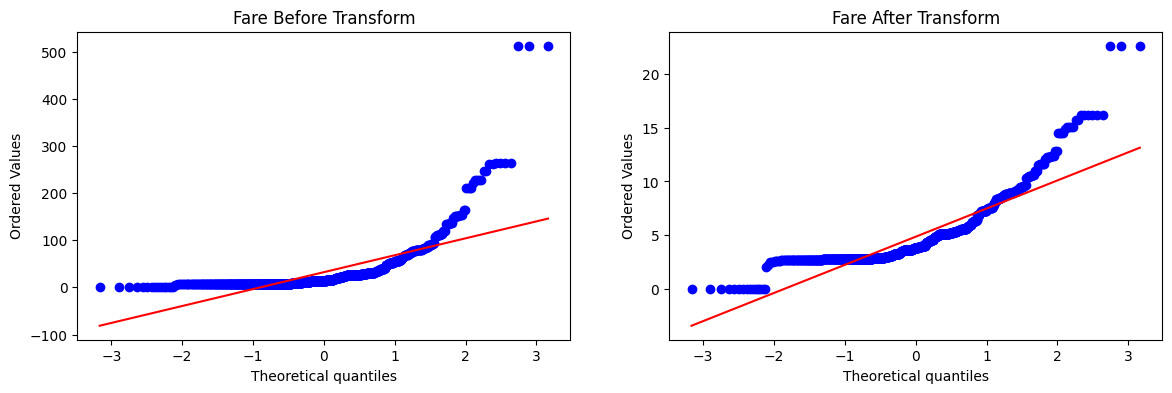

In [55]:
apply_transform(lambda x: np.sqrt(x))